# ST_Polyline(\[ST_Point\])

Create a polyline geometry from an array of point geometry.

In [2]:
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F

In [3]:
data = [(0.0, 0.0, 50.0, 50.0, 100.0, 20.0)]

In [4]:
df = spark.createDataFrame(
    data, "x1 double,y1 double," "x2 double,y2 double," "x3 double,y3 double"
)

In [5]:
pdf = df.select(
    S.st_polyline(
        S.st_point("x1", "y1"),
        S.st_point("x2", "y2"),
        S.st_point("x3", "y3"),
    ).alias("geometry")
).toPandas()

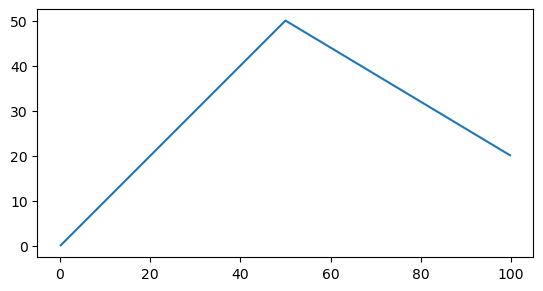

In [6]:
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot()